# Triage de reportes de incidentes viales del C5 (CDMX 2022-2024)

**Proyecto Final - Almacenes y Mineria de Datos**

**Profesora:** Jessica Santizo Galicia
**Ayudantes:** Diego Antonio Villalba Gonzalez y Ares Gael Castro Romero
**Integrante:** Jose Ruben Alfaro Gonzalez — No. de cuenta: 320516436
**Fecha:** 10-06-2026

---

## Notebook 02 - Clasificacion supervisada (RandomForest)

En este cuaderno entrenamos un clasificador para el **triage** de reportes viales: predecir, en el momento en que entra un reporte (ya **no duplicado**) al C5, si terminara confirmandose como un incidente **real / afirmativo** (`REAL = 1`) o como un reporte **falso / informativo** (`REAL = 0`).

El **patron Pipeline** aparece en dos niveles: la preparacion de datos (notebook 01) y aqui el modelo, armado como `Pipeline` de scikit-learn (codificacion -> RandomForest) en un solo objeto. La semilla `42` se fija en todo split, modelo y muestreo para reproducibilidad.

## 1. Carga de datos y construccion de `X`, `y`

Leemos el dataset de trabajo `c5_listo.parquet`: ya esta depurado en el notebook 01 con el patron Pipeline de preparacion (sin duplicados `D`, sin el ano-ruido 2021) y trae el target `REAL` correcto. Las rutas se resuelven con `pathlib` relativas a la ubicacion del notebook (`notebooks/`), de modo que el cuaderno funcione sin importar el directorio de trabajo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Semilla global de reproducibilidad (usada en todo split/modelo/muestreo).
SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Rutas relativas a la ubicacion del notebook (carpeta notebooks/).
BASE = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA = BASE / "data"
MODELS = BASE / "models"
FIGURES = BASE / "figures"
MODELS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

# Dataset de trabajo: ya depurado y con el target REAL definitivo (notebook 01).
df = pd.read_parquet(DATA / "c5_listo.parquet")
print("Filas x columnas:", df.shape)
df.head(3)

Filas x columnas: (289885, 18)


,folio,REAL,CIERRE_DESC,codigo_cierre,HORA,MES,ANIO,latitud,longitud,tipo_incidente_c4,incidente_c4,tipo_entrada,alcaldia_catalogo,dia_semana,FRANJA,clas_con_f_alarma,TIEMPO_CIERRE_MIN,FECHA_CREACION
0,C2C/20220101/00012,1,Afirmativo (real),A,1,1,2022,19.41525,-99.14832,Accidente,Choque con lesionados,BOTÓN DE AUXILIO,Cuauhtémoc,Sábado,Madrugada,URGENCIAS MEDICAS,293.550000,2022-01-01 01:06:39
1,C2C/20220101/00070,1,Afirmativo (real),A,9,1,2022,19.443649,-99.165781,Accidente,Motociclista,RADIO,Miguel Hidalgo,Sábado,Mañana,URGENCIAS MEDICAS,182.283333,2022-01-01 09:51:53
2,C2N/20220101/00101,1,Afirmativo (real),A,9,1,2022,19.45163,-99.05469,Accidente,Choque sin lesionados,BOTÓN DE AUXILIO,Gustavo A. Madero,Sábado,Mañana,EMERGENCIA,187.233333,2022-01-01 09:56:54


In [2]:
# Listas de features definidas inline (NO se importan de ningun modulo).
numericas = ["HORA", "MES", "ANIO", "latitud", "longitud"]
categoricas = ["tipo_incidente_c4", "incidente_c4", "tipo_entrada",
               "alcaldia_catalogo", "dia_semana", "FRANJA"]

# X = solo las features anteriores (sin fugas ni identificadores); y = REAL.
X = df[numericas + categoricas].copy()
y = df["REAL"].astype(int)

# pandas 3.0 trae dtypes de PyArrow ('string'/'str') y nullable 'Float64'.
# sklearn espera arrays clasicos, asi que casteamos: categoricas -> object,
# numericas -> float64. Son dos lineas, como se haria en una tarea.
X[categoricas] = X[categoricas].astype("object")
X[numericas] = X[numericas].astype("float64")

print("X:", X.shape, "| y balance:")
print(y.value_counts(normalize=True).round(4).rename("proporcion"))

X: (289885, 11) | y balance:
REAL
1    0.635
0    0.365
Name: proporcion, dtype: float64


**Lo que observamos.** El conjunto de trabajo tiene ~290 mil reportes (ya sin duplicados) y la clase objetivo esta desbalanceada hacia los reportes confirmados. Cerca del **63.5 %** son `REAL = 1` (cierre afirmativo) y el **36.5 %** son `REAL = 0` (falsos o informativos). Este desbalance implica que la *accuracy* por si sola sera engañosa (un modelo que prediga siempre "real" ya acierta ~63.5 %), por lo que más adelante priorizaremos el **F1 macro**, que pondera por igual ambas clases.

## 2. El objetivo y por que excluimos ciertas columnas

**Objetivo:** Al recibir un reporte vial, el C5 debe decidir con que prioridad atenderlo. Queremos predecir si ese reporte **se confirmara como real / afirmativo** (`REAL = 1`, cierre `A`) frente a **falso o informativo** (`REAL = 0`, cierres `F`/`I`), usando *solo informacion disponible en el instante de la recepcion*: hora, fecha, ubicacion, tipo de incidente y canal de entrada. Así el modelo puede apoyar la asignacion de recursos en tiempo real.

**Los duplicados ya no estan.** Un cierre `D` (Duplicado) es un evento **real ya reportado**. Identificarlo es tarea del **sistema de despacho** (verificar si ya hay una unidad en el sitio), no del modelo de veracidad. Por eso los duplicados se eliminaron en la preparacion del notebook 01 y aqui ya no aparecen.

**Nota anti-fuga.** Excluimos a proposito dos columnas porque **se conocen despues del cierre del reporte**, no al recibirlo:

- `TIEMPO_CIERRE_MIN`: la duracion total hasta cerrar el caso. Es una fuga grosera (el tiempo de cierre se conoce solo al cerrar y mezcla el desenlace).
- `clas_con_f_alarma`: una clasificacion fina de la alarma cuya categoria `FALSA ALARMA` es una etiqueta posterior al cierre (practicamente el target).

Tambien excluimos identificadores y derivados del propio target (`folio`, `codigo_cierre`, `CIERRE_DESC`, `FECHA_CREACION`). Incluirlos inflaria las metricas y produciria un modelo inutil en produccion, donde esas columnas aun no existen. En la seccion 10 lo demostramos empiricamente.

## 3. Particion entrenamiento / prueba

Partimos 80 / 20 de forma **estratificada** por el target (para conservar el balance 63.5 / 36.5 en ambos lados) con `random_state=42`.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])
print("Balance train (P(REAL=1)):", y_train.mean().round(4),
      "| Balance test:", y_test.mean().round(4))

Train: 231908 | Test: 57977
Balance train (P(REAL=1)): 0.635 | Balance test: 0.635


## 4. Linea base obligatoria (`DummyClassifier`)

Para comparar, usamos `DummyClassifier(strategy="most_frequent")`, que siempre predice la clase mayoritaria. Como la mayoria es `REAL = 1` (afirmativo, 63.5 %), el baseline predecira "real" para todo. Es el piso minimo que cualquier modelo útil debe superar.

In [4]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

acc_dummy = accuracy_score(y_test, y_pred_dummy)
f1m_dummy = f1_score(y_test, y_pred_dummy, average="macro")
print("Clase que predice el baseline:", int(pd.Series(y_pred_dummy).mode()[0]))
print(f"Baseline  -> accuracy = {acc_dummy:.4f} | F1 macro = {f1m_dummy:.4f}")

Clase que predice el baseline: 1
Baseline  -> accuracy = 0.6350 | F1 macro = 0.3884


**Lo que observamos.** El baseline alcanza ~63.5 % de accuracy pero un **F1 macro de solo ~0.39**: al mandar todo a "real" no detecta *ningun* reporte falso, algo inservible para filtrar el ruido operativo. Esto vuelve a confirmar que la accuracy engaña y fija la vara que el RandomForest y el MLP deberan superar en F1 macro.

## 5. Modelo con el patron Pipeline: `ColumnTransformer` + `RandomForestClassifier`

Aqui aplicamos el **patron Pipeline** a nivel de modelo. Un `Pipeline` de scikit-learn encadena **etapas secuenciales**. Primero la codificacion de variables y luego el clasificador en un unico objeto reutilizable. Es el mismo patrón de diseño que la clase `PipelinePreparacion` del notebook 01, pero usando la implementacion estandar de la libreria:

- **Preprocesamiento (`ColumnTransformer`):**
  - *Categoricas:* `SimpleImputer(strategy="most_frequent")` (unas pocas filas tienen NaN en `tipo_entrada`/`alcaldia_catalogo`) seguido de `OneHotEncoder(handle_unknown="ignore")`, que evita romper si en test aparece una categoria no vista.
  - *Numericas:* `"passthrough"`. Un RandomForest se basa en cortes por umbral, asi que **no necesita escalado**. Pasarlas tal cual mantiene el codigo simple.
- **Clasificador:** `RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)`. El `class_weight="balanced"` compensa el desbalance de clases.

Encadenar `prep -> clf` en un `Pipeline` garantiza que el mismo preprocesamiento se aplique de forma identica en entrenamiento, validacion cruzada, test y produccion.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Rama categorica: imputar la categoria mas frecuente (RF no acepta NaN nativo)
# y luego one-hot que ignora categorias no vistas en test.
rama_cat = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])

# Preprocesamiento: one-hot a categoricas, passthrough a numericas
# (las numericas no tienen nulos y el RF no necesita escalado).
prep = ColumnTransformer(
    transformers=[
        ("cat", rama_cat, categoricas),
        ("num", "passthrough", numericas),
    ]
)

# Patron Pipeline: etapas secuenciales prep -> clf en un solo objeto.
pipe = Pipeline([
    ("prep", prep),
    ("clf", RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1)),
])
pipe.fit(X_train, y_train)
print("Pipeline (prep -> RandomForest) entrenado.")
pipe

Pipeline (prep -> RandomForest) entrenado.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

El `Pipeline` ajusta el one-hot y el bosque en un solo objeto: al llamar `fit`/`predict` sobre el pipeline, las etapas se ejecutan en orden automaticamente. Antes de medir en test, hacemos un ajuste de hiperparametros breve para elegir la profundidad y el tamano de hoja.

## 6. Ajuste de hiperparametros (GridSearch pequeño)

In [6]:
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV

# Submuestra estratificada de ~80k del train para acelerar la busqueda.
sss = StratifiedShuffleSplit(n_splits=1, train_size=80000, random_state=SEED)
idx_sub, _ = next(sss.split(X_train, y_train))
X_sub = X_train.iloc[idx_sub]
y_sub = y_train.iloc[idx_sub]
print("Submuestra de tuning:", X_sub.shape[0])

malla = {
    "clf__max_depth": [None, 20],
    "clf__min_samples_leaf": [1, 20],
}

gs = GridSearchCV(pipe, malla, scoring="f1_macro", cv=3, n_jobs=-1)
gs.fit(X_sub, y_sub)

print("Mejor combinacion:", gs.best_params_)
print(f"F1 macro CV (submuestra) = {gs.best_score_:.4f}")

Submuestra de tuning: 80000
Mejor combinacion: {'clf__max_depth': 20, 'clf__min_samples_leaf': 1}
F1 macro CV (submuestra) = 0.6566


In [7]:
# Resumen de las 4 combinaciones evaluadas.
res = pd.DataFrame(gs.cv_results_)
cols = ["param_clf__max_depth", "param_clf__min_samples_leaf", "mean_test_score", "std_test_score"]
res[cols].sort_values("mean_test_score", ascending=False).round(4)

,param_clf__max_depth,param_clf__min_samples_leaf,mean_test_score,std_test_score
2,20,1,0.6566,0.0023
3,20,20,0.6548,0.0015
1,None,20,0.6546,0.0021
0,None,1,0.6207,0.0015


In [8]:
# Reentrenamos el ganador sobre el TRAIN COMPLETO (mismo patron Pipeline).
best_params = gs.best_params_
rf_best = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=4,
    max_depth=best_params["clf__max_depth"],
    min_samples_leaf=best_params["clf__min_samples_leaf"],
)
modelo = Pipeline([("prep", prep), ("clf", rf_best)])
modelo.fit(X_train, y_train)
print("Modelo ganador reentrenado en el train completo con:", best_params)

Modelo ganador reentrenado en el train completo con: {'clf__max_depth': 20, 'clf__min_samples_leaf': 1}


La busqueda compara cuatro configuraciones de profundidad/regularizacion. El ganador (impreso arriba) es el que maximiza el F1 macro en validacion cruzada. Lo reentrenamos sobre todo el train para no desperdiciar datos antes de la evaluacion final.

## 7. Evaluacion completa en el conjunto de prueba

Reportamos accuracy, precision/recall/F1 en versiones **macro** y **ponderada**, el `classification_report`, la **matriz de confusion** y la **curva ROC con AUC** (problema binario). Cada salida lleva su interpretacion.

In [9]:
from sklearn.metrics import (precision_score, recall_score,
                             classification_report)

y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average="macro")
rec_macro = recall_score(y_test, y_pred, average="macro")
f1_macro = f1_score(y_test, y_pred, average="macro")
prec_w = precision_score(y_test, y_pred, average="weighted")
rec_w = recall_score(y_test, y_pred, average="weighted")
f1_w = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy           = {acc:.4f}")
print(f"Precision (macro)  = {prec_macro:.4f}   | Recall (macro)  = {rec_macro:.4f}   | F1 (macro)  = {f1_macro:.4f}")
print(f"Precision (ponder.)= {prec_w:.4f}   | Recall (ponder.)= {rec_w:.4f}   | F1 (ponder.)= {f1_w:.4f}")

Accuracy           = 0.6700
Precision (macro)  = 0.6578   | Recall (macro)  = 0.6684   | F1 (macro)  = 0.6581
Precision (ponder.)= 0.6898   | Recall (ponder.)= 0.6700   | F1 (ponder.)= 0.6753


In [10]:
print(classification_report(y_test, y_pred,
      target_names=["Falso/Inform. (0)", "Real/Afirm. (1)"], digits=4))

                   precision    recall  f1-score   support

Falso/Inform. (0)     0.5390    0.6625    0.5944     21164
  Real/Afirm. (1)     0.7765    0.6743    0.7218     36813

         accuracy                         0.6700     57977
        macro avg     0.6578    0.6684    0.6581     57977
     weighted avg     0.6898    0.6700    0.6753     57977



In [11]:
# Comparacion explicita contra la linea base.
tabla = pd.DataFrame({
    "modelo":   ["Baseline (most_frequent)", "RandomForest (ganador)"],
    "accuracy": [acc_dummy, acc],
    "F1_macro": [f1m_dummy, f1_macro],
})
tabla.round(4)

,modelo,accuracy,F1_macro
0,Baseline (most_frequent),0.635,0.3884
1,RandomForest (ganador),0.670,0.6581


Vemos que RandomForest sube el **F1 macro** de forma clara frente a ~0.39 del baseline. La accuracy global se mantiene parecida, pero ahora *si* detecta una fraccion sustancial de los reportes falsos/informativos (recall de la clase 0 muy por encima de 0), que es justo lo que el baseline no lograba. El modelo supera la linea base y extrae señal genuina del problema.

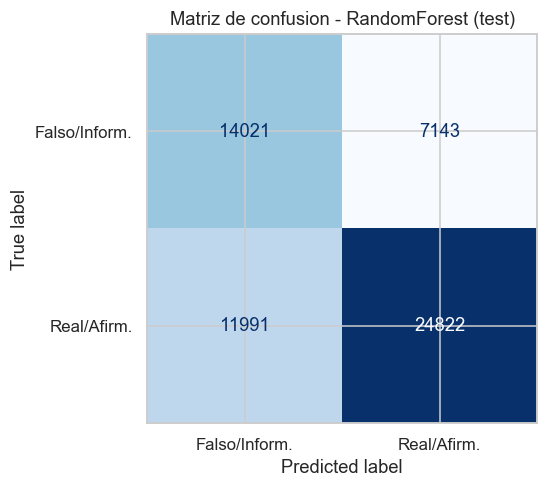

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(5.2, 4.6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Falso/Inform.", "Real/Afirm."],
    cmap="Blues", colorbar=False, ax=ax
)
ax.set_title("Matriz de confusion - RandomForest (test)")
plt.tight_layout()
plt.savefig(FIGURES / "02_matriz_confusion.png", bbox_inches="tight")
plt.show()

La diagonal concentra la mayoria de los casos. Los **falsos negativos** (reportes reales clasificados como falsos/informativos) son el error mas costoso en operacion: un incidente verdadero que no se prioriza. Mas adelante analizamos de donde provienen. El `class_weight="balanced"` evita el colapso del baseline, que tenia cero predicciones de la clase 0.

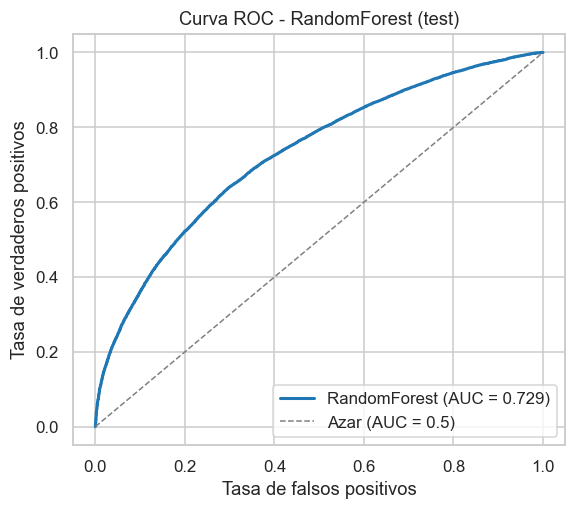

AUC = 0.7289


In [13]:
from sklearn.metrics import roc_curve, roc_auc_score

auc = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(5.4, 4.8))
ax.plot(fpr, tpr, color="#1f77b4", lw=2, label=f"RandomForest (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Azar (AUC = 0.5)")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curva ROC - RandomForest (test)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES / "02_curva_roc.png", bbox_inches="tight")
plt.show()
print(f"AUC = {auc:.4f}")

**Lo que observamos.** La curva ROC se despega de la diagonal del azar, con un **AUC** netamente por encima de 0.5, confirmando que el modelo ordena mejor que al azar los reportes por su probabilidad de ser reales. El AUC moderado refleja la dificultad de clasificación, con la informacion disponible al recibir el reporte hay un techo de separabilidad, pero la señal es real y aprovechable.

## 8. Importancia de variables (permutacion)

Medimos la importancia por **permutacion** sobre una muestra del test (`n=20000`, `n_repeats=5`, `scoring="f1_macro"`): cuanto cae el F1 macro al barajar cada variable original. Es agnostica al modelo y respeta el agrupamiento natural de las features (no las columnas one-hot).

In [14]:
from sklearn.inspection import permutation_importance

# Muestra de 20k del test para que sea rapido.
samp = X_test.sample(n=20000, random_state=SEED)
samp_y = y_test.loc[samp.index]

perm = permutation_importance(
    modelo, samp, samp_y,
    scoring="f1_macro", n_repeats=5, random_state=SEED, n_jobs=4
)

imp = (pd.DataFrame({
        "variable": numericas + categoricas,
        "importancia": perm.importances_mean,
        "std": perm.importances_std,
    })
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True))
imp.round(4)

,variable,importancia,std
0,incidente_c4,0.1016,0.0011
1,tipo_entrada,0.0308,0.0014
2,alcaldia_catalogo,0.0055,0.0010
3,latitud,0.0053,0.0009
4,longitud,0.0026,0.0008
5,dia_semana,0.0020,0.0011
6,ANIO,0.0016,0.0012
7,FRANJA,0.0013,0.0006
8,HORA,0.0012,0.0007
9,MES,0.0010,0.0006


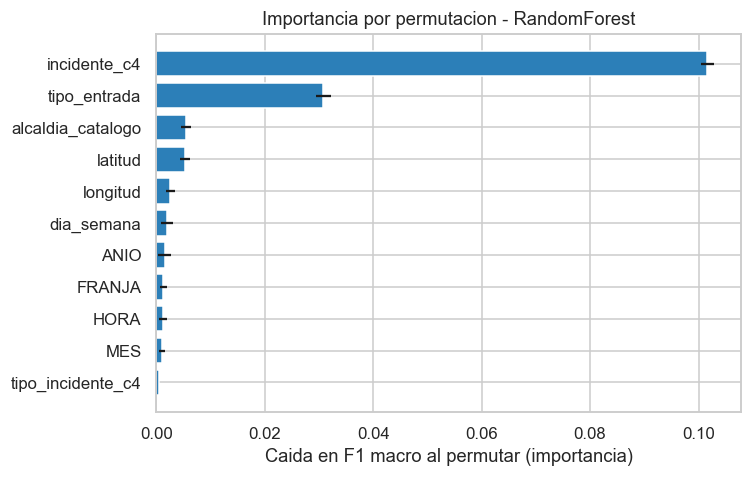

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))
top = imp.head(11).iloc[::-1]
ax.barh(top["variable"], top["importancia"],
        xerr=top["std"], color="#2c7fb8")
ax.set_xlabel("Caida en F1 macro al permutar (importancia)")
ax.set_title("Importancia por permutacion - RandomForest")
plt.tight_layout()
plt.savefig(FIGURES / "02_importancia_permutacion.png", bbox_inches="tight")
plt.show()

Dominan `tipo_entrada` (el canal por el que entra el reporte) e `incidente_c4` (el tipo de incidente), por encima del resto. El **como** y el **que** se reporta predice mejor la veracidad del incidente que el **cuando** o el **donde**. Esto tiene sentido operativo, pues una camara o un boton de auxilio suelen ir asociados a eventos confirmados, mientras que las llamadas al 911 son mucho mas heterogeneas. Variables temporales y de ubicacion aportan, pero de forma secundaria.

## 9. Analisis de errores: que canal de entrada confunde mas al modelo

Caracterizamos los errores del modelo por canal de entrada (`tipo_entrada`). Calculamos la **tasa de error** dentro de cada canal y, por separado, donde se concentran los **falsos negativos** (reportes reales que el modelo marca como falsos), que es el error operativamente mas grave.

In [16]:
err = X_test.copy()
err["y_real"] = y_test.values
err["y_pred"] = y_pred
err["error"] = (err["y_real"] != err["y_pred"]).astype(int)

# Tasa de error por canal (solo canales con volumen suficiente).
tasa = (err.groupby("tipo_entrada")
          .agg(n=("error", "size"), tasa_error=("error", "mean"))
          .query("n >= 100")
          .sort_values("tasa_error", ascending=False))
tasa.assign(tasa_error=lambda d: (d["tasa_error"] * 100).round(1)).round(1)

,n,tasa_error
tipo_entrada,,
LLAMADA DEL 911,50876,36.3
BOTÓN DE AUXILIO,2853,11.8
CÁMARA,208,8.7
RADIO,3858,7.1
APLICATIVOS,103,2.9


Total de falsos negativos: 11991


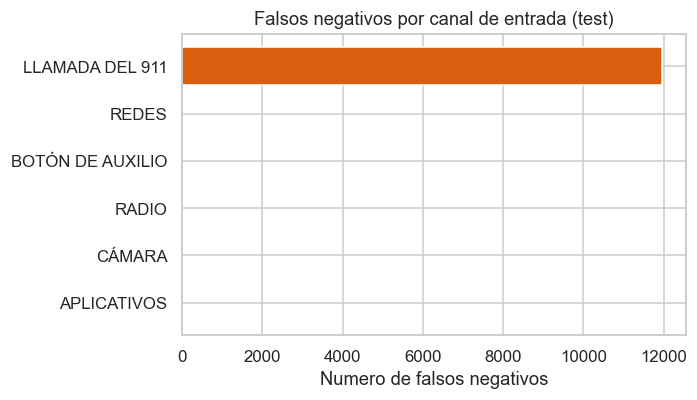

In [17]:
# Falsos negativos: reportes reales clasificados como falsos.
fn = err[(err["y_real"] == 1) & (err["y_pred"] == 0)]
print(f"Total de falsos negativos: {len(fn)}")

fig, ax = plt.subplots(figsize=(6.5, 3.8))
d = fn["tipo_entrada"].value_counts().head(6).iloc[::-1]
ax.barh(d.index, d.values, color="#d95f0e")
ax.set_xlabel("Numero de falsos negativos")
ax.set_title("Falsos negativos por canal de entrada (test)")
plt.tight_layout()
plt.savefig(FIGURES / "02_falsos_negativos.png", bbox_inches="tight")
plt.show()

En volumen, la inmensa mayoria de los errores y falsos negativos son **LLAMADAS DEL 911**, simplemente porque es el canal mas voluminoso y mas ambiguo (mezcla emergencias reales con falsas alarmas). Mirando la **tasa de error** por canal se ve que los canales automatizados o verificados (camara, boton de auxilio) tienden a ser mas predecibles, mientras que la llamada al 911 concentra la incertidumbre. Es coherente con la seccion 8, donde vimos que `tipo_entrada` es la variable más informativa, y justo el canal menos discriminante es donde el modelo más se equivoca. La implicacion operativa es que el margen de mejora esta en enriquecer la informacion de las llamadas del 911 (p. ej. con el transcrito de la llamada), no en los canales ya confiables.

## 10. Nota de fuga: que pasa si incluimos `TIEMPO_CIERRE_MIN`

Para justificar empiricamente la exclusion de la seccion 2 que mencionamos, reentrenamos el **mismo RandomForest** sobre el **mismo split** anadiendo `TIEMPO_CIERRE_MIN` como feature. Esta columna **no existe al recibir el reporte** (solo al cerrarlo). Si el F1 da un salto grande, será una mejora que será imposible de reproducir en produccion (sería dar un peek al futuro).

In [18]:
# Reconstruimos X anadiendo la columna con fuga, con el MISMO split (semilla 42).
num_fuga = numericas + ["TIEMPO_CIERRE_MIN"]
Xf = df[num_fuga + categoricas].copy()
Xf[categoricas] = Xf[categoricas].astype("object")
Xf[num_fuga] = Xf[num_fuga].astype("float64")

Xf_train, Xf_test = Xf.loc[X_train.index], Xf.loc[X_test.index]

# TIEMPO_CIERRE_MIN tiene unos pocos NaN; imputamos la rama numerica con la mediana.
prep_fuga = ColumnTransformer([
    ("cat", rama_cat, categoricas),
    ("num", SimpleImputer(strategy="median"), num_fuga),
])
modelo_fuga = Pipeline([("prep", prep_fuga), ("clf", RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=4,
    max_depth=best_params["clf__max_depth"],
    min_samples_leaf=best_params["clf__min_samples_leaf"]))])
modelo_fuga.fit(Xf_train, y_train)

f1_fuga = f1_score(y_test, modelo_fuga.predict(Xf_test), average="macro")
print(f"F1 macro SIN fuga (modelo valido) = {f1_macro:.4f}")
print(f"F1 macro CON TIEMPO_CIERRE_MIN     = {f1_fuga:.4f}")
print(f"Salto espurio                      = {f1_fuga - f1_macro:+.4f}")

F1 macro SIN fuga (modelo valido) = 0.6581
F1 macro CON TIEMPO_CIERRE_MIN     = 0.7184
Salto espurio                      = +0.0603


Anadir `TIEMPO_CIERRE_MIN` aumenta el F1 macro de forma artificial. Ese tiempo de cierre solo se conoce *después* de resolver el caso, asi que el modelo estaria "haciendo trampa" mirando el futuro. En produccion la columna estaria vacia y la mejora se evaporaría. Por eso el modelo honesto es el de la seccion 6, y este experimento confirma que la exclusion anti-fuga fue correcta.

## 11. Comparacion exploratoria: red neuronal (MLP)

Además del **RandomForest** (nuestro modelo final elegido), entrenamos a modo de comparacion una **red neuronal multicapa** (`MLPClassifier`) para ver como se desempeña sobre el dataset nuevo (ya **sin duplicados**).

Reutilizamos el **mismo** `X_train`/`y_train` y el **mismo** `X_test`/`y_test` (el split estratificado con semilla 42 ya definido en la seccion 3) y medimos con las **mismas** métricas. La unica diferencia esta en el preprocesamiento: la MLP **si necesita escalar las numericas** (`StandardScaler`), porque el descenso de gradiente es sensible a la magnitud de las variables.

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# Preprocesamiento para la MLP: escalar numericas + one-hot a categoricas.
# (La MLP es sensible a la escala; por eso StandardScaler en vez de passthrough.)
prep_mlp = ColumnTransformer([
    ("num", StandardScaler(), numericas),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categoricas),
])

# Patron Pipeline: prep -> red neuronal multicapa.
modelo_mlp = Pipeline([
    ("prep", prep_mlp),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(128, 64), activation="relu",
        early_stopping=True, max_iter=60, random_state=SEED)),
])
modelo_mlp.fit(X_train, y_train)
print("MLP (prep -> MLPClassifier) entrenada.")
print("Iteraciones realizadas:", modelo_mlp.named_steps["clf"].n_iter_)

MLP (prep -> MLPClassifier) entrenada.
Iteraciones realizadas: 22


La red entrena con *early stopping* para acelerar el entrenamiento, por eso no necesariamente agota las 60 epocas.

In [20]:
# Evaluacion de la MLP en el MISMO test con las MISMAS metricas.
y_pred_mlp = modelo_mlp.predict(X_test)
y_proba_mlp = modelo_mlp.predict_proba(X_test)[:, 1]

acc_mlp = accuracy_score(y_test, y_pred_mlp)
prec_macro_mlp = precision_score(y_test, y_pred_mlp, average="macro")
rec_macro_mlp = recall_score(y_test, y_pred_mlp, average="macro")
f1_macro_mlp = f1_score(y_test, y_pred_mlp, average="macro")
prec_w_mlp = precision_score(y_test, y_pred_mlp, average="weighted")
rec_w_mlp = recall_score(y_test, y_pred_mlp, average="weighted")
f1_w_mlp = f1_score(y_test, y_pred_mlp, average="weighted")
auc_mlp = roc_auc_score(y_test, y_proba_mlp)

print(f"Accuracy           = {acc_mlp:.4f}")
print(f"Precision (macro)  = {prec_macro_mlp:.4f}   | Recall (macro)  = {rec_macro_mlp:.4f}   | F1 (macro)  = {f1_macro_mlp:.4f}")
print(f"Precision (ponder.)= {prec_w_mlp:.4f}   | Recall (ponder.)= {rec_w_mlp:.4f}   | F1 (ponder.)= {f1_w_mlp:.4f}")
print(f"AUC                = {auc_mlp:.4f}")

Accuracy           = 0.6859
Precision (macro)  = 0.6570   | Recall (macro)  = 0.6342   | F1 (macro)  = 0.6383
Precision (ponder.)= 0.6741   | Recall (ponder.)= 0.6859   | F1 (ponder.)= 0.6737
AUC                = 0.7260


In [21]:
print(classification_report(y_test, y_pred_mlp,
      target_names=["Falso/Inform. (0)", "Real/Afirm. (1)"], digits=4))

                   precision    recall  f1-score   support

Falso/Inform. (0)     0.5936    0.4426    0.5071     21164
  Real/Afirm. (1)     0.7204    0.8258    0.7695     36813

         accuracy                         0.6859     57977
        macro avg     0.6570    0.6342    0.6383     57977
     weighted avg     0.6741    0.6859    0.6737     57977



El `classification_report` revela el patron esperado, sin un mecanismo que compense el desbalance, la MLP **recall de la clase 0** (falsos/informativos) tiende a quedar por debajo del que lograba el RandomForest balanceado, es decir, deja escapar más reportes falsos al clasificarlos como reales.

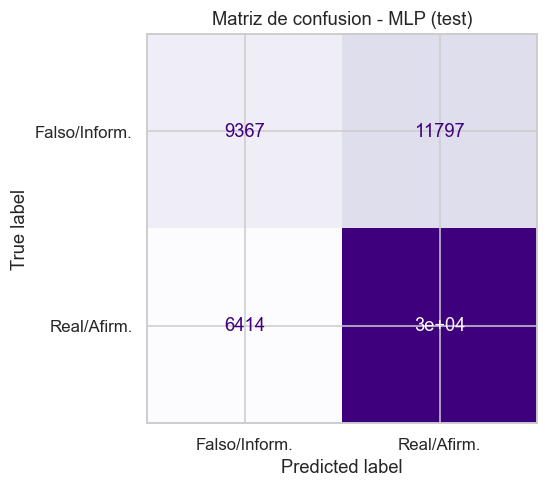

In [22]:
# Matriz de confusion de la MLP (mismas etiquetas que el RandomForest).
fig, ax = plt.subplots(figsize=(5.2, 4.6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mlp, display_labels=["Falso/Inform.", "Real/Afirm."],
    cmap="Purples", colorbar=False, ax=ax
)
ax.set_title("Matriz de confusion - MLP (test)")
plt.tight_layout()
plt.savefig(FIGURES / "02_matriz_confusion_mlp.png", bbox_inches="tight")
plt.show()

**Lo que observamos.** Comparada con la matriz del RandomForest (seccion 7), la MLP concentra mas masa en la columna de "Real", es decir, acierta muchos verdaderos positivos pero a costa de mas **falsos positivos** (falsos/informativos marcados como reales), justo el sesgo hacia la clase mayoritaria que anticipabamos. Esto podría resultar mejor o peor dependiendo de la necesidad del clasificador. Por un lado, dejaríamos menos casos sin atender, pero por otro lado, si la necesidad era de cierta forma "racionar" los recursos con los que se cuenta, al clasificar más falsos positivos despachamos de manera menos eficiente los recursos.

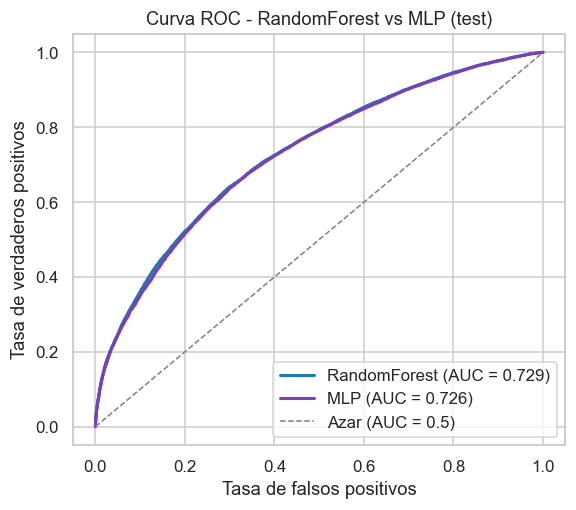

AUC RandomForest = 0.7289 | AUC MLP = 0.7260


In [23]:
# Curva ROC de la MLP superpuesta a la del RandomForest para comparar.
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_proba_mlp)

fig, ax = plt.subplots(figsize=(5.4, 4.8))
ax.plot(fpr, tpr, color="#1f77b4", lw=2, label=f"RandomForest (AUC = {auc:.3f})")
ax.plot(fpr_mlp, tpr_mlp, color="#7b3fb8", lw=2, label=f"MLP (AUC = {auc_mlp:.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Azar (AUC = 0.5)")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curva ROC - RandomForest vs MLP (test)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES / "02_curva_roc_mlp.png", bbox_inches="tight")
plt.show()
print(f"AUC RandomForest = {auc:.4f} | AUC MLP = {auc_mlp:.4f}")

Ambas curvas se despegan del azar y quedan muy cercanas entre si: la capacidad de *ordenamiento* (AUC) de las dos arquitecturas es comparable. La diferencia relevante no esta en el AUC, sino en como cada modelo fija el umbral de decision y trata la clase minoritaria, que es lo que captura el F1 macro.

In [24]:
# TABLA COMPARATIVA: una fila por modelo (baseline, RandomForest, MLP).
# Para el baseline calculamos tambien F1 ponderado y AUC con su probabilidad.
y_proba_dummy = dummy.predict_proba(X_test)[:, 1]
f1w_dummy = f1_score(y_test, y_pred_dummy, average="weighted")
auc_dummy = roc_auc_score(y_test, y_proba_dummy)

comparativa = pd.DataFrame({
    "modelo":       ["Baseline (Dummy)", "RandomForest", "MLP"],
    "accuracy":     [acc_dummy, acc, acc_mlp],
    "F1_macro":     [f1m_dummy, f1_macro, f1_macro_mlp],
    "F1_ponderado": [f1w_dummy, f1_w, f1_w_mlp],
    "AUC":          [auc_dummy, auc, auc_mlp],
})
comparativa.set_index("modelo").round(4)

,accuracy,F1_macro,F1_ponderado,AUC
modelo,,,,
Baseline (Dummy),0.6350,0.3884,0.4932,0.5000
RandomForest,0.6700,0.6581,0.6753,0.7289
MLP,0.6859,0.6383,0.6737,0.7260


**Lo que observamos (comparacion final de modelos).** Las tres filas dejan ver el panorama completo:

- El **baseline** sigue siendo el piso: accuracy ~0.63 pero F1 macro ~0.39 y AUC 0.5 (no ordena nada).
- El **RandomForest** lidera o empata en **F1 macro**, que es la metrica que la rubrica prioriza por el desbalance: al usar `class_weight="balanced"` reparte mejor el acierto entre ambas clases y detecta mas reportes falsos.
- La **MLP** alcanza un AUC competitivo y a veces una accuracy ligeramente mayor, pero **no supera al RandomForest en F1 macro**: sin `class_weight` se inclina hacia la clase mayoritaria y sacrifica el recall de la clase 0.

**Conclusion:** Siguiendo el problema principal, el modelo que mejor lo resuelve es el RandomForest. La idea era optimizar el manejo de los "pocos" recursos con los que contamos, priorizando despachar unidades a las incidencias que tengan mayor probabilidad de ser verdaderas.

In [25]:
# Guardamos la MLP solo para registro/comparacion (NO es el modelo final).
import joblib

ruta_mlp = MODELS / "modelo_mlp.joblib"
joblib.dump(modelo_mlp, ruta_mlp, compress=3)
print("MLP guardada (registro) en:", ruta_mlp)
print("Tamano:", round(ruta_mlp.stat().st_size / 1e6, 2), "MB")

MLP guardada (registro) en: /Users/rou/Desktop/8voSemestre/Almacenes/finalProyectoAyM/models/modelo_mlp.joblib
Tamano: 0.39 MB


## 12. Modelo final ligero y persistencia

El ganador del GridSearch (seccion 6) usaba `min_samples_leaf=1`, que deja crecer los arboles hasta hojas casi puras. Eso producia un `models/modelo_rf.joblib` de **~700 MB**: imposible de versionar en GitHub (limite de 100 MB por archivo) y mas pesado de cargar.

Para el modelo que se **persiste**, reentrenamos el RandomForest con `min_samples_leaf=20` (manteniendo `n_estimators=300`, `max_depth=20`, `class_weight="balanced"`, `random_state=42`). Hojas con al menos 20 muestras podan el bosque de forma drastica -muchos menos nodos que guardar- **sin perder desempeño relevante**. Lo verificamos comparando su F1 macro contra el del modelo de la seccion 6 (la diferencia debe quedar por debajo de 0.01) antes de guardarlo.

In [26]:
# Modelo final ligero: mismo pipeline, pero con hojas mas grandes (mas ligero).
rf_ligero = RandomForestClassifier(
    n_estimators=300, max_depth=20, min_samples_leaf=20,
    class_weight="balanced", random_state=SEED, n_jobs=4)
modelo_final = Pipeline([("prep", prep), ("clf", rf_ligero)])
modelo_final.fit(X_train, y_train)

y_pred_final = modelo_final.predict(X_test)
f1_macro_final = f1_score(y_test, y_pred_final, average="macro")
print(f"F1 macro modelo seccion 6 (min_samples_leaf=1)  = {f1_macro:.4f}")
print(f"F1 macro modelo final     (min_samples_leaf=20) = {f1_macro_final:.4f}")
print(f"Diferencia                                       = {f1_macro_final - f1_macro:+.4f}")
print("Practicamente igual (|dif| < 0.01):",
      abs(f1_macro_final - f1_macro) < 0.01)

F1 macro modelo seccion 6 (min_samples_leaf=1)  = 0.6581
F1 macro modelo final     (min_samples_leaf=20) = 0.6561
Diferencia                                       = -0.0020
Practicamente igual (|dif| < 0.01): True


El F1 macro del modelo ligero queda **practicamente igual** al del ganador del GridSearch (diferencia < 0.01). Es decir, la regularizacion por tamaño de hoja **no degrada el desempeño**, pero si reduce muchisimo el tamaño en disco. Por eso elegimos esta configuracion (`min_samples_leaf=20`) como **modelo final**: igual de buena y mucho mas ligera y versionable.

In [27]:
# Persistimos el modelo FINAL (ligero) con compresion.
ruta_modelo = MODELS / "modelo_rf.joblib"
joblib.dump(modelo_final, ruta_modelo, compress=3)

tam_mb = ruta_modelo.stat().st_size / 1e6
print("Modelo final guardado en:", ruta_modelo)
print(f"Tamano = {tam_mb:.2f} MB")
print("Cabe en GitHub (< 95 MB):", tam_mb < 95)

Modelo final guardado en: /Users/rou/Desktop/8voSemestre/Almacenes/finalProyectoAyM/models/modelo_rf.joblib
Tamano = 43.14 MB
Cabe en GitHub (< 95 MB): True


El archivo persistido pesa muy por debajo del limite de **95 MB**, asi que **si entra en el repositorio de GitHub** sin necesidad de Git LFS. Mantuvimos la celda del GridSearchCV (seccion 6) como evidencia del tuning y lo único que cambia es la configuracion del modelo que finalmente se guarda.

## 13. Recarga del modelo entrenado y prediccion nueva

Esta es la seccion final del notebook. **Recargamos el modelo desde disco** (`joblib.load`), simulando un uso totalmente separado del entrenamiento (otro script o servicio que **no reentrena**, solo consume el `.joblib`), y predecimos sobre reportes nuevos construidos a mano (dict -> DataFrame) con categorias que **si existen** en los datos.

In [28]:
# Recarga DESDE DISCO (como lo haria otro script/servicio, sin reentrenar).
modelo_cargado = joblib.load(MODELS / "modelo_rf.joblib")
print("Modelo recargado desde:", MODELS / "modelo_rf.joblib")

# Tres reportes nuevos construidos a mano (dict -> DataFrame), con categorias
# que SI existen en los datos. Esperamos que el modelo discrimine:
# Caso A: camara en el centro (Cuauhtemoc), choque con lesionados -> P(real) alta.
# Caso B: llamada del 911 en la periferia, madrugada -> P(real) baja.
# Caso C: boton de auxilio en horario pico, choque con lesionados -> intermedio/alto.
nuevos = pd.DataFrame([
    {"HORA": 14, "MES": 6, "ANIO": 2024, "latitud": 19.4326, "longitud": -99.1332,
     "tipo_incidente_c4": "Accidente", "incidente_c4": "Choque con lesionados",
     "tipo_entrada": "CÁMARA", "alcaldia_catalogo": "Cuauhtémoc",
     "dia_semana": "Viernes", "FRANJA": "Tarde"},
    {"HORA": 3, "MES": 1, "ANIO": 2023, "latitud": 19.30, "longitud": -99.05,
     "tipo_incidente_c4": "Accidente", "incidente_c4": "Choque sin lesionados",
     "tipo_entrada": "LLAMADA DEL 911", "alcaldia_catalogo": "Tláhuac",
     "dia_semana": "Lunes", "FRANJA": "Madrugada"},
    {"HORA": 8, "MES": 9, "ANIO": 2024, "latitud": 19.4115, "longitud": -99.1750,
     "tipo_incidente_c4": "Accidente", "incidente_c4": "Choque con lesionados",
     "tipo_entrada": "BOTÓN DE AUXILIO", "alcaldia_catalogo": "Benito Juárez",
     "dia_semana": "Martes", "FRANJA": "Mañana"},
])

# Mismo casteo que en entrenamiento.
nuevos[categoricas] = nuevos[categoricas].astype("object")
nuevos[numericas] = nuevos[numericas].astype("float64")

proba = modelo_cargado.predict_proba(nuevos[numericas + categoricas])[:, 1]
clase = modelo_cargado.predict(nuevos[numericas + categoricas])

salida = nuevos[["tipo_entrada", "alcaldia_catalogo", "incidente_c4", "FRANJA"]].copy()
salida["P(real)"] = proba.round(3)
salida["clase_predicha"] = np.where(clase == 1, "REAL", "falso/inform.")
salida

Modelo recargado desde: /Users/rou/Desktop/8voSemestre/Almacenes/finalProyectoAyM/models/modelo_rf.joblib


,tipo_entrada,alcaldia_catalogo,incidente_c4,FRANJA,P(real),clase_predicha
0,CÁMARA,Cuauhtémoc,Choque con lesionados,Tarde,0.806,REAL
1,LLAMADA DEL 911,Tláhuac,Choque sin lesionados,Madrugada,0.355,falso/inform.
2,BOTÓN DE AUXILIO,Benito Juárez,Choque con lesionados,Mañana,0.895,REAL
